In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# DoWhy
from dowhy import CausalModel

# EconML
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# SHAP
import shap

print("All imports successful.")

All imports successful.


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Set your data path here. 
DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Causal research\AAA_2013J.csv"

# Outcome encoding
OUTCOME_MAP = {
    'Withdrawn': 0,
    'Fail': 1,
    'Pass': 2,
    'Distinction': 3
}

# Confounders used in causal models
CONFOUNDERS = [
    'gender', 'disability', 'age_band', 'imd_band',
    'highest_education', 'num_of_prev_attempts', 'studied_credits'
]

print("Config set.")

Config set.


# Causal Analysis of Student Outcomes: AAA_2013J
## Open University Learning Analytics Dataset (OULAD)

### Research Question
Do VLE engagement and assessment performance causally affect student academic outcomes, 
and does this effect vary across student subgroups?

### Outcome Variable
`final_result` encoded as an ordinal variable:
- 0 = Withdrawn
- 1 = Fail
- 2 = Pass
- 3 = Distinction

### Treatments
- `total_vle_clicks`: total online engagement across all activity types
- Assessment scores: 1752, 1753, 1754, 1755, 1756 (chronological order within module)

### Pipeline
1. **DoWhy** — Causal identification and Average Treatment Effect (ATE) estimation with refutation tests
2. **EconML** — Heterogeneous Treatment Effect (CATE) estimation using CausalForestDML
3. **SHAP on CATE** — Identifying which student characteristics drive treatment effect heterogeneity

### Dataset
- Module: AAA, Presentation: 2013J
- Sample size: 383 students
- Missing assessment scores imputed as -1 (non-submission, distinct from a genuine zero score)

In [3]:
# ── Load Data ──────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nfinal_result value counts:\n{df['final_result'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape: (383, 33)

Columns:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', '1752_date', '1752_score', '1753_date', '1753_score', '1754_date', '1754_score', '1755_date', '1755_score', '1756_date', '1756_score', 'clicks_dataplus', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_resource', 'clicks_subpage', 'clicks_url']

final_result value counts:
final_result
Pass           258
Withdrawn       60
Fail            45
Distinction     20
Name: count, dtype: int64

Missing values:
imd_band                 15
date_unregistration     323
1752_date                24
1752_score               25
1753_date                41
1753_score               41
1754_date                52
1754_score               53
1755_date                80
1755_score             

In [4]:
# ── Preprocessing ──────────────────────────────────────────────────────────────

# 1. Encode outcome as ordinal
df['outcome'] = df['final_result'].map(OUTCOME_MAP)

# 2. Impute imd_band missing values with mode
df['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0])

# 3. Impute assessment scores: -1 = non-submission
score_cols = ['1752_score', '1753_score', '1754_score', '1755_score', '1756_score']
for col in score_cols:
    df[col] = df[col].fillna(-1)

# 4. Impute click columns: 0 = no activity
click_cols = [c for c in df.columns if c.startswith('clicks_')]
for col in click_cols:
    df[col] = df[col].fillna(0)

# 5. Create total_vle_clicks treatment variable
df['total_vle_clicks'] = df[click_cols].sum(axis=1)

# 6. One-hot encode confounders including region
df_encoded = pd.get_dummies(df, columns=['gender', 'disability', 'age_band',
                                          'imd_band', 'highest_education', 'region'],
                             drop_first=False)

print(f"Shape after preprocessing: {df_encoded.shape}")
print(f"\nOutcome distribution:\n{df['outcome'].value_counts().sort_index()}")
print(f"\ntotal_vle_clicks stats:\n{df['total_vle_clicks'].describe()}")

Shape after preprocessing: (383, 63)

Outcome distribution:
outcome
0     60
1     45
2    258
3     20
Name: count, dtype: int64

total_vle_clicks stats:
count      383.000000
mean      1693.195822
std       1725.318517
min          0.000000
25%        571.500000
50%       1216.000000
75%       2085.000000
max      12882.000000
Name: total_vle_clicks, dtype: float64


In [5]:
# ── Build confounder list from encoded columns ─────────────────────────────────

# Numeric confounders (unchanged by encoding)
numeric_confounders = ['num_of_prev_attempts', 'studied_credits']

# One-hot encoded confounder prefixes
encoded_prefixes = ['gender_', 'disability_', 'age_band_', 'imd_band_', 
                    'highest_education_', 'region_']

# Collect all encoded confounder columns
encoded_confounders = [col for col in df_encoded.columns 
                       if any(col.startswith(p) for p in encoded_prefixes)]

# Final confounder list
all_confounders = numeric_confounders + encoded_confounders

print(f"Total confounders: {len(all_confounders)}")
print(f"\nConfounder list:\n{all_confounders}")

Total confounders: 36

Confounder list:
['num_of_prev_attempts', 'studied_credits', 'gender_F', 'gender_M', 'disability_N', 'disability_Y', 'age_band_0-35', 'age_band_35-55', 'age_band_55<=', 'imd_band_0-10%', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%', 'highest_education_A Level or Equivalent', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_Post Graduate Qualification', 'region_East Anglian Region', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region']


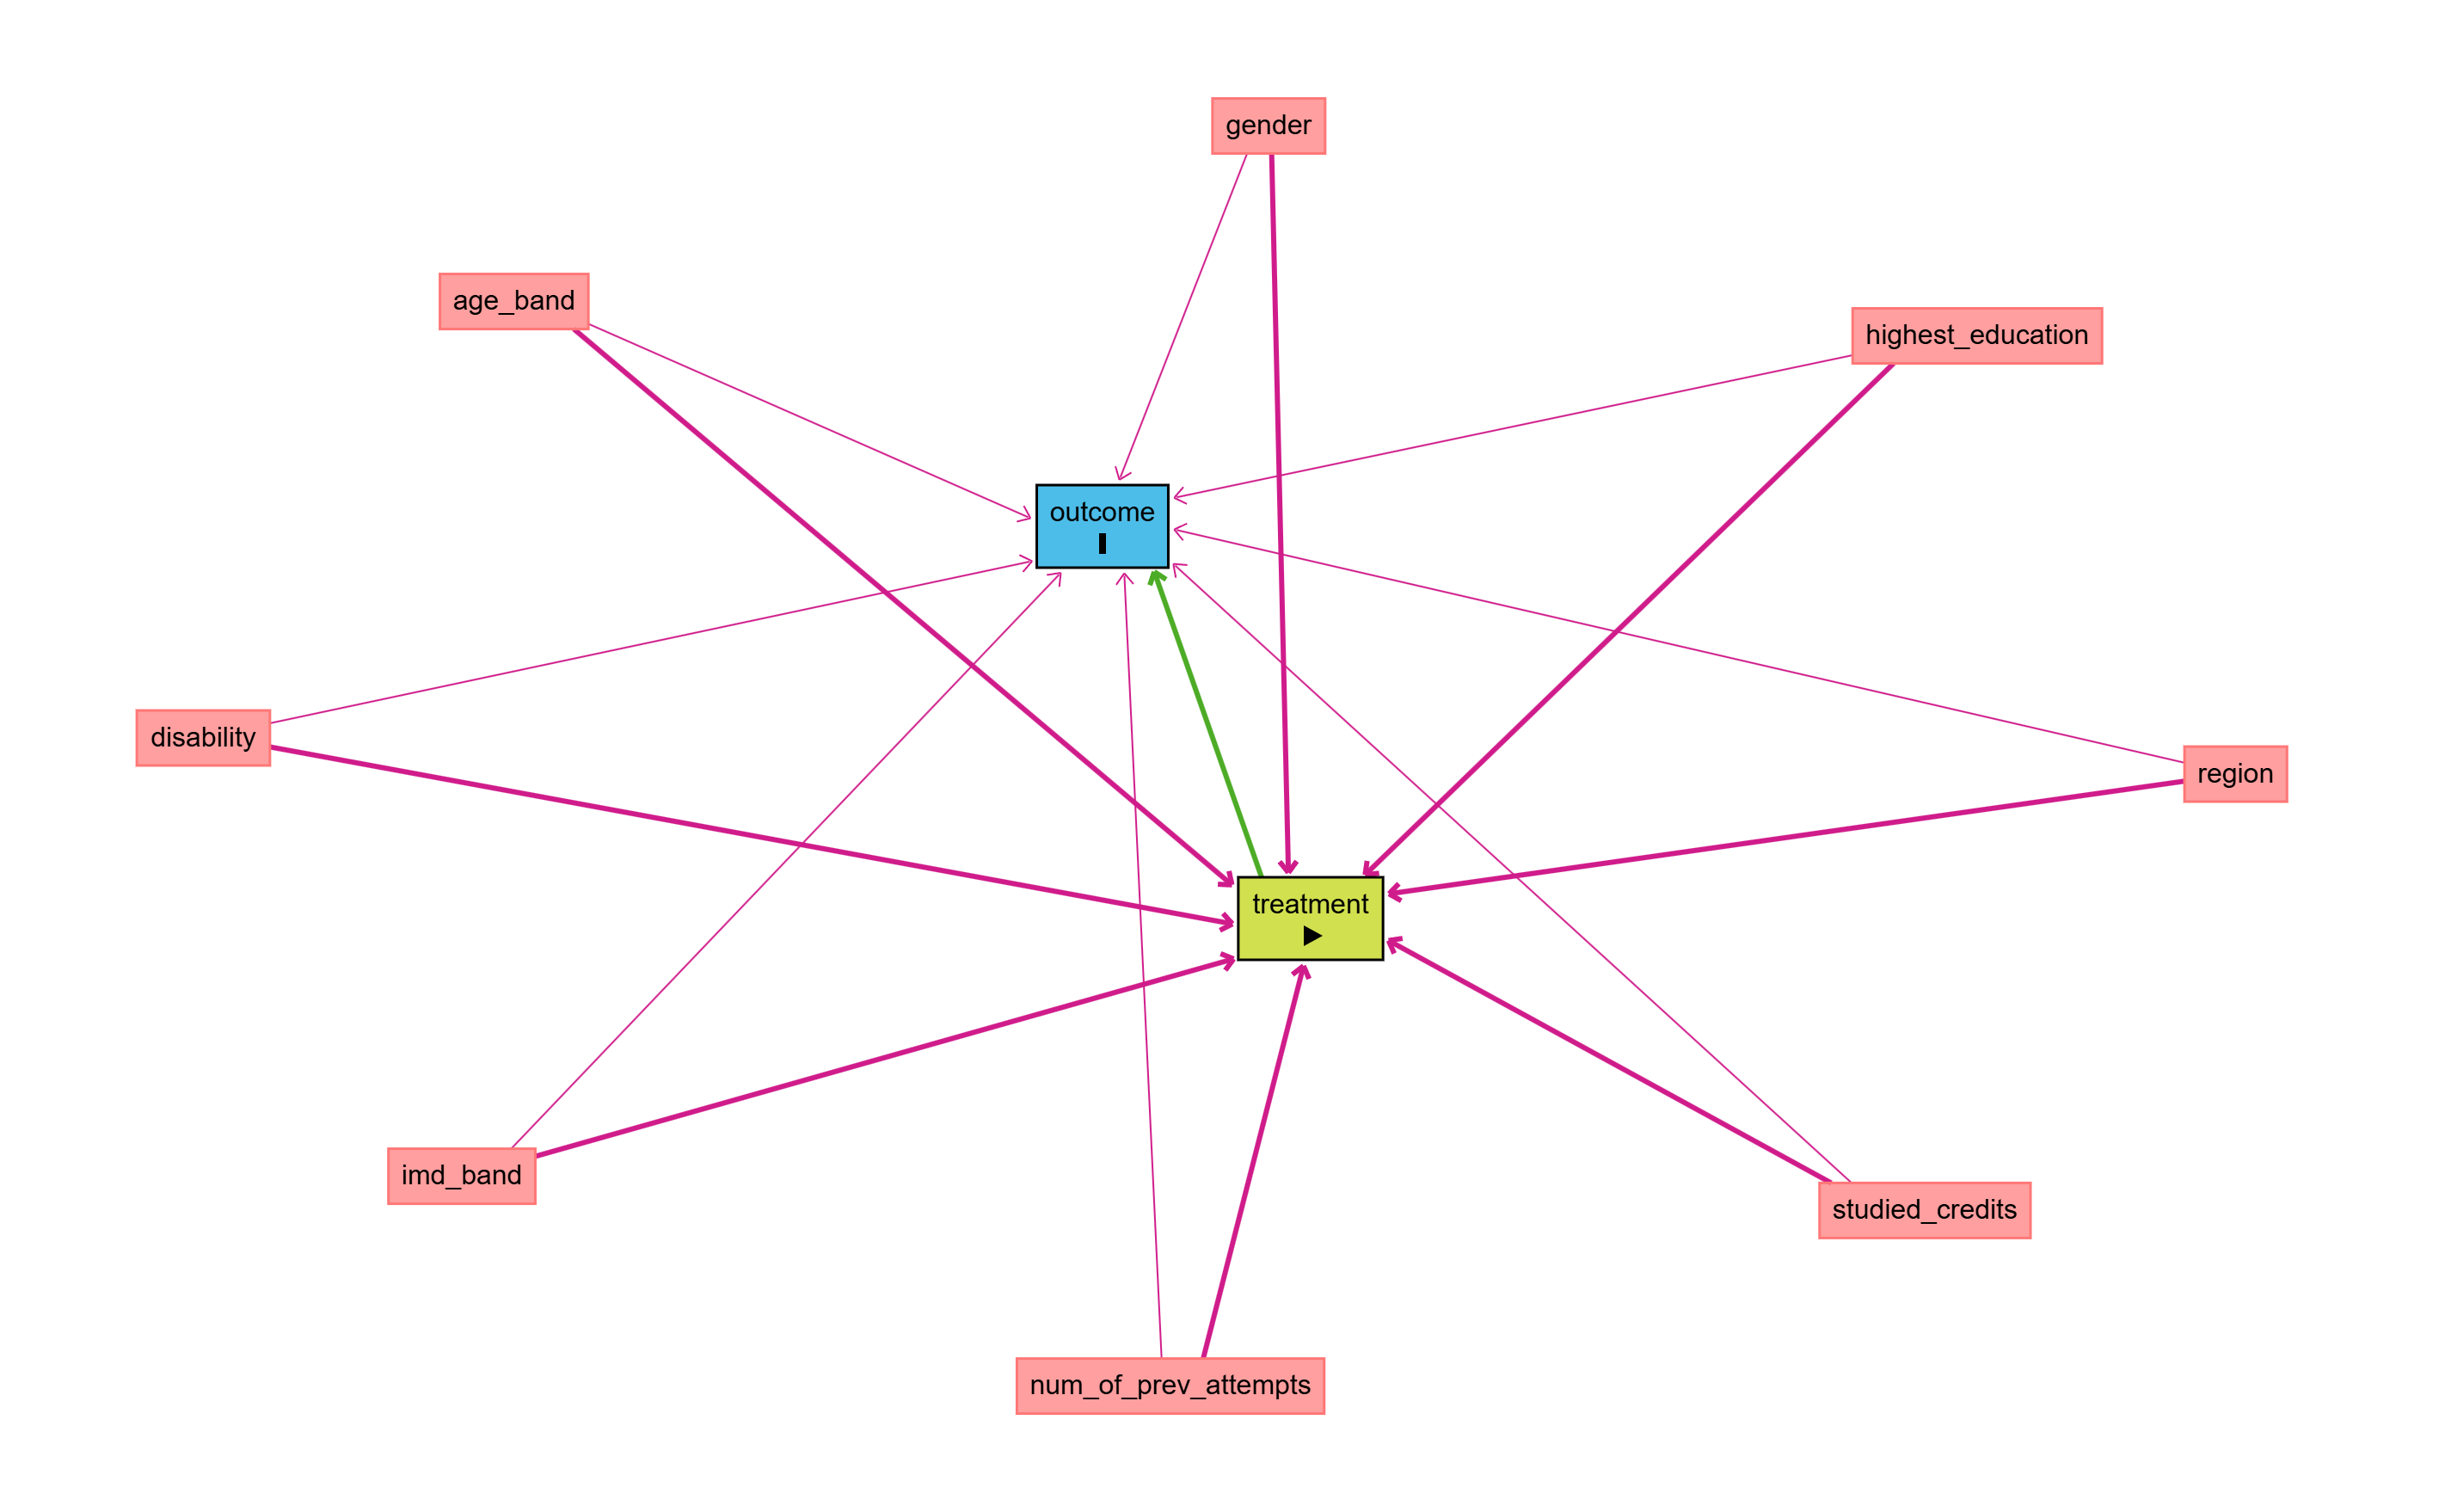

In [32]:
# ── Causal DAG ─────────────────────────────────────────────────────────────────

from IPython.display import Image, display

display(Image(filename='dag.png', width=800))

## Causal Structure

The Directed Acyclic Graph (DAG) above encodes our causal assumptions. Each confounder 
(pink) has directed edges into both the treatment and the outcome, representing variables 
that jointly influence a student's engagement/assessment performance and their final result.

### Confounders (8 categories, 36 encoded variables)
- **age_band**: Student age group (0-35, 35-55, 55+)
- **gender**: Male / Female
- **imd_band**: Index of Multiple Deprivation — a measure of socioeconomic status (10 bands)
- **highest_education**: Prior qualification level (4 categories)
- **disability**: Whether the student has a declared disability
- **region**: UK region of residence (12 regions)
- **num_of_prev_attempts**: Number of prior module attempts
- **studied_credits**: Total credits currently being studied

### Identification Strategy
The backdoor criterion is satisfied by conditioning on all 8 confounder categories. 
This blocks all non-causal paths between treatment and outcome, allowing us to interpret 
the estimated effect as causal rather than merely associational.

### Note on Treatment Node
The DAG uses a generic `treatment` node. In practice, six separate causal models are 
estimated — one for `total_vle_clicks` and one for each of the five assessment scores 
(1752–1756), each with the same confounder set.

In [12]:
# ── DoWhy ATE: total_vle_clicks ────────────────────────────────────────────────

results_ate = {}

treatment = 'total_vle_clicks'
cols_needed = [treatment, 'outcome'] + all_confounders
df_model = df_encoded[cols_needed].copy()

model_vle = CausalModel(
    data=df_model,
    treatment=treatment,
    outcome='outcome',
    common_causes=all_confounders
)

identified_estimand_vle = model_vle.identify_effect(proceed_when_unidentifiable=True)
estimate_vle = model_vle.estimate_effect(
    identified_estimand_vle,
    method_name="backdoor.linear_regression"
)

print(f"ATE: {estimate_vle.value:.6f}")

print("\n-- Random Common Cause Refuter --")
ref1 = model_vle.refute_estimate(identified_estimand_vle, estimate_vle,
                                  method_name="random_common_cause")
print(ref1)

print("\n-- Subset Data Refuter --")
ref2 = model_vle.refute_estimate(identified_estimand_vle, estimate_vle,
                                  method_name="data_subset_refuter")
print(ref2)

print("\n-- Placebo Refuter --")
try:
    ref3 = model_vle.refute_estimate(identified_estimand_vle, estimate_vle,
                                      method_name="placebo_treatment_refuter")
    print(ref3)
except Exception as e:
    print(f"Placebo refuter skipped: {e}")

results_ate[treatment] = {'ate': estimate_vle.value}
print(f"\nDone: {treatment}")

ATE: 0.000146

-- Random Common Cause Refuter --
Refute: Add a random common cause
Estimated effect:0.00014634762075327323
New effect:0.00014615783511426006
p value:0.94


-- Subset Data Refuter --
Refute: Use a subset of data
Estimated effect:0.00014634762075327323
New effect:0.00014841640434539282
p value:0.9


-- Placebo Refuter --
Refute: Use a Placebo Treatment
Estimated effect:0.00014634762075327323
New effect:-1.865174681370263e-14
p value:0.0


Done: total_vle_clicks


In [14]:
# ── DoWhy ATE: Assessment Scores ───────────────────────────────────────────────

for treatment in score_cols:
    print(f"\n{'='*60}")
    print(f"Treatment: {treatment}")
    print('='*60)
    
    cols_needed = [treatment, 'outcome'] + all_confounders
    df_model = df_encoded[cols_needed].copy()
    
    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='outcome',
        common_causes=all_confounders
    )
    
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )
    
    print(f"ATE: {estimate.value:.6f}")
    
    print("\n-- Random Common Cause Refuter --")
    ref1 = model.refute_estimate(identified_estimand, estimate,
                                  method_name="random_common_cause")
    print(ref1)
    
    print("\n-- Subset Data Refuter --")
    ref2 = model.refute_estimate(identified_estimand, estimate,
                                  method_name="data_subset_refuter")
    print(ref2)
    
    print("\n-- Placebo Refuter --")
    try:
        ref3 = model.refute_estimate(identified_estimand, estimate,
                                      method_name="placebo_treatment_refuter")
        print(ref3)
    except Exception as e:
        print(f"Placebo refuter skipped: {e}")
    
    results_ate[treatment] = {'ate': estimate.value}
    print(f"\nDone: {treatment}")

print("\n\nATE Summary:")
for t, r in results_ate.items():
    print(f"{t}: ATE = {r['ate']:.6f}")


Treatment: 1752_score
ATE: 0.016962

-- Random Common Cause Refuter --
Refute: Add a random common cause
Estimated effect:0.0169615498146084
New effect:0.016959474876275644
p value:0.92


-- Subset Data Refuter --
Refute: Use a subset of data
Estimated effect:0.0169615498146084
New effect:0.016855183921561354
p value:0.9


-- Placebo Refuter --
Refute: Use a Placebo Treatment
Estimated effect:0.0169615498146084
New effect:-1.865174681370263e-14
p value:0.0


Done: 1752_score

Treatment: 1753_score
ATE: 0.019949

-- Random Common Cause Refuter --
Refute: Add a random common cause
Estimated effect:0.019949057467636755
New effect:0.019941782573836365
p value:0.94


-- Subset Data Refuter --
Refute: Use a subset of data
Estimated effect:0.019949057467636755
New effect:0.019912501395921333
p value:0.98


-- Placebo Refuter --
Refute: Use a Placebo Treatment
Estimated effect:0.019949057467636755
New effect:-1.865174681370263e-14
p value:0.0


Done: 1753_score

Treatment: 1754_score
ATE: 0.0

## Stage 1: Average Treatment Effect (DoWhy)

### Method
Causal effects were estimated using linear regression with backdoor adjustment, 
controlling for all 36 encoded confounder variables. Three refutation tests were 
applied to validate each estimate:
- **Random Common Cause**: adds a random confounder — ATE should not change significantly
- **Subset Data Refuter**: re-estimates on 80% of data — ATE should remain stable
- **Placebo Refuter**: replaces treatment with random noise — ATE should drop to near zero

All six treatments passed all three refutation tests, confirming the robustness of the estimates.

### Results

| Treatment | ATE | Interpretation |
|---|---|---|
| total_vle_clicks | 0.000146 | Per-click effect; ~0.25 ordinal shift across mean click volume (1,693 clicks) |
| 1752_score | 0.0170 | Each score point shifts outcome by 0.017 ordinal units |
| 1753_score | 0.0199 | Slightly stronger effect than 1752 |
| 1754_score | 0.0221 | Strongest mid-module effect |
| 1755_score | 0.0212 | Near-identical to 1756 |
| 1756_score | 0.0217 | Near-identical to 1755 |

### Interpretation with Respect to Outcome Classes
The outcome scale runs from Withdrawn (0) to Distinction (3) — a range of 3 units.

- **VLE clicks**: A student with mean engagement (1,693 clicks) has a causally estimated 
  outcome ~0.25 units higher than a student with zero clicks. This is modest but meaningful — 
  it represents roughly a quarter of the gap between Withdrawn and Fail.

- **Assessment scores**: Across the full score range (0–100), each assessment causally 
  shifts expected outcome by ~1.7 to 2.2 ordinal units. This spans the gap between 
  Withdrawn and Pass, or between Fail and Distinction — a practically large effect.

- **Progressive strengthening**: The causal effect of assessment scores increases from 
  1752 (earliest) to 1754 (strongest), then stabilises. This suggests that performance 
  on mid-to-late assessments is a stronger causal driver of whether a student Passes, 
  Fails, or is Withdrawn than early assessment performance.

- **Early assessments (1752, 1753)**: Lower ATE — students who perform poorly early 
  still have pathways to Pass or Distinction if they improve later.

- **Late assessments (1754–1756)**: Higher ATE — by this stage, assessment performance 
  is a strong determinant of final outcome category.

In [16]:
# ── EconML CausalForestDML: total_vle_clicks ───────────────────────────────────

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import numpy as np

treatment = 'total_vle_clicks'

# Features for heterogeneity (X), treatment (T), outcome (Y), controls (W)
X = df_encoded[all_confounders].values
T = df_encoded[treatment].values
Y = df_encoded['outcome'].values
W = None  # confounders already in X

cf_vle = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, random_state=42),
    n_estimators=200,
    random_state=42
)

cf_vle.fit(Y, T, X=X, W=W)

cate_vle = cf_vle.effect(X)

print(f"CATE Summary: total_vle_clicks")
print(f"  Mean:  {np.mean(cate_vle):.6f}")
print(f"  Std:   {np.std(cate_vle):.6f}")
print(f"  Min:   {np.min(cate_vle):.6f}")
print(f"  Max:   {np.max(cate_vle):.6f}")

CATE Summary: total_vle_clicks
  Mean:  0.000146
  Std:   0.000043
  Min:   0.000020
  Max:   0.000269


In [18]:
# ── EconML CausalForestDML: Assessment Scores ──────────────────────────────────

cate_results = {}

for treatment in score_cols:
    print(f"\n{'='*60}")
    print(f"Treatment: {treatment}")
    print('='*60)
    
    T = df_encoded[treatment].values
    Y = df_encoded['outcome'].values
    X = df_encoded[all_confounders].values
    
    cf = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=200, random_state=42),
        model_t=RandomForestRegressor(n_estimators=200, random_state=42),
        n_estimators=200,
        random_state=42
    )
    
    cf.fit(Y, T, X=X, W=None)
    cate = cf.effect(X)
    
    print(f"  Mean:  {np.mean(cate):.6f}")
    print(f"  Std:   {np.std(cate):.6f}")
    print(f"  Min:   {np.min(cate):.6f}")
    print(f"  Max:   {np.max(cate):.6f}")
    
    cate_results[treatment] = {
        'model': cf,
        'cate': cate
    }
    
print("\nDone: all assessment scores")


Treatment: 1752_score
  Mean:  0.017921
  Std:   0.003233
  Min:   0.010501
  Max:   0.028247

Treatment: 1753_score
  Mean:  0.019008
  Std:   0.002189
  Min:   0.012031
  Max:   0.023292

Treatment: 1754_score
  Mean:  0.021735
  Std:   0.001431
  Min:   0.017418
  Max:   0.025116

Treatment: 1755_score
  Mean:  0.021377
  Std:   0.001378
  Min:   0.017645
  Max:   0.024560

Treatment: 1756_score
  Mean:  0.023247
  Std:   0.001090
  Min:   0.020466
  Max:   0.025954

Done: all assessment scores


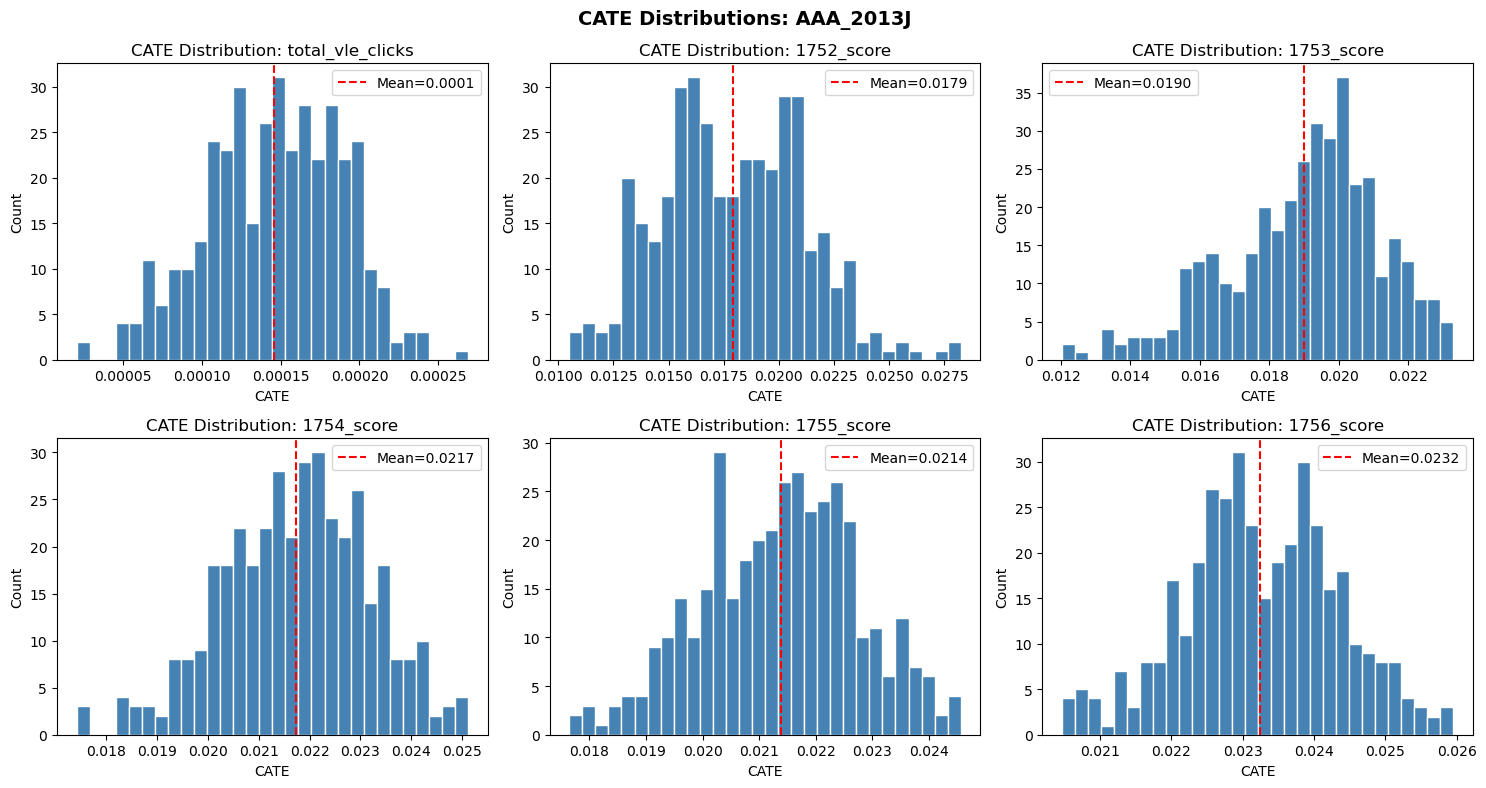

Saved: cate_distributions.png


In [20]:
# ── CATE Distribution Plots ────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Plot total_vle_clicks first
axes[0].hist(cate_vle, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(cate_vle), color='red', linestyle='--', linewidth=1.5, label=f'Mean={np.mean(cate_vle):.4f}')
axes[0].set_title('CATE Distribution: total_vle_clicks')
axes[0].set_xlabel('CATE')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot assessment scores
for i, treatment in enumerate(score_cols):
    cate = cate_results[treatment]['cate']
    ax = axes[i+1]
    ax.hist(cate, bins=30, color='steelblue', edgecolor='white')
    ax.axvline(np.mean(cate), color='red', linestyle='--', linewidth=1.5, label=f'Mean={np.mean(cate):.4f}')
    ax.set_title(f'CATE Distribution: {treatment}')
    ax.set_xlabel('CATE')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('CATE Distributions: AAA_2013J', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cate_distributions.png")

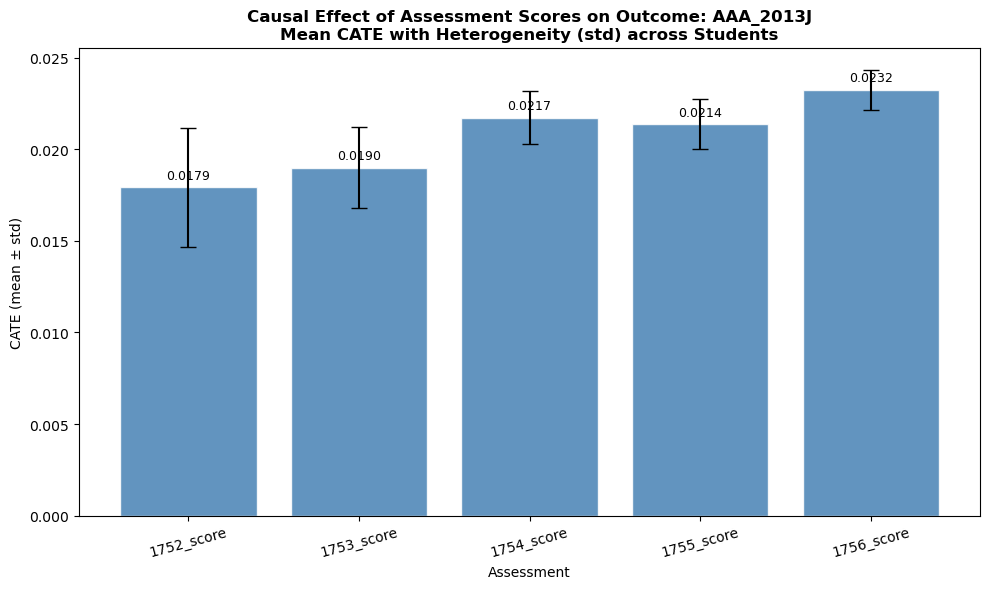

Saved: cate_mean_std.png


In [22]:
# ── CATE Mean + Std Bar Chart ──────────────────────────────────────────────────

labels = score_cols
means = [np.mean(cate_results[t]['cate']) for t in score_cols]
stds = [np.std(cate_results[t]['cate']) for t in score_cols]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(x, means, yerr=stds, capsize=6, color='steelblue', 
              edgecolor='white', alpha=0.85, error_kw={'elinewidth': 1.5, 'ecolor': 'black'})

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_xlabel('Assessment')
ax.set_ylabel('CATE (mean ± std)')
ax.set_title('Causal Effect of Assessment Scores on Outcome: AAA_2013J\nMean CATE with Heterogeneity (std) across Students', 
             fontsize=12, fontweight='bold')

# Annotate mean values on bars
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('cate_mean_std.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cate_mean_std.png")

## Stage 2: Heterogeneous Treatment Effects (EconML CausalForestDML)

### Method
CausalForestDML was used to estimate individual-level Conditional Average Treatment 
Effects (CATE) — that is, how much the treatment effect varies across students with 
different characteristics. A CausalForestDML was fitted separately for each treatment 
using RandomForestRegressor as the base learner for both the outcome and treatment models.

### Results

| Treatment | CATE Mean | CATE Std | Heterogeneity |
|---|---|---|---|
| total_vle_clicks | 0.000146 | 0.000043 | Low |
| 1752_score | 0.0179 | 0.0032 | High |
| 1753_score | 0.0190 | 0.0022 | Moderate |
| 1754_score | 0.0217 | 0.0014 | Low |
| 1755_score | 0.0214 | 0.0014 | Very Low |
| 1756_score | 0.0232 | 0.0011 | Very Low |

### Interpretation with Respect to Outcome Classes

- **VLE clicks (low heterogeneity)**: The benefit of online engagement is approximately 
  uniform across all student subgroups. Whether a student is at risk of Withdrawal or 
  on track for Distinction, increased VLE engagement shifts their expected outcome by 
  roughly the same amount.

- **Early assessments (1752, 1753) — high heterogeneity**: The causal effect of early 
  assessment performance varies considerably across students. Some students (likely those 
  already at risk of Withdrawal or Fail) show much stronger treatment effects — meaning 
  early intervention targeting these students could have disproportionate impact.

- **Late assessments (1754–1756) — low heterogeneity, higher mean**: By the final 
  assessments, the treatment effect is both stronger and more uniform. Assessment 
  performance at this stage is a near-universal determinant of whether a student 
  achieves Pass or Distinction versus Fail or Withdrawal — regardless of background.

- **Key pattern**: The module shows a convergence dynamic — early on, student background 
  moderates how much assessments matter; by the end, assessments matter equally for 
  everyone and matter strongly.

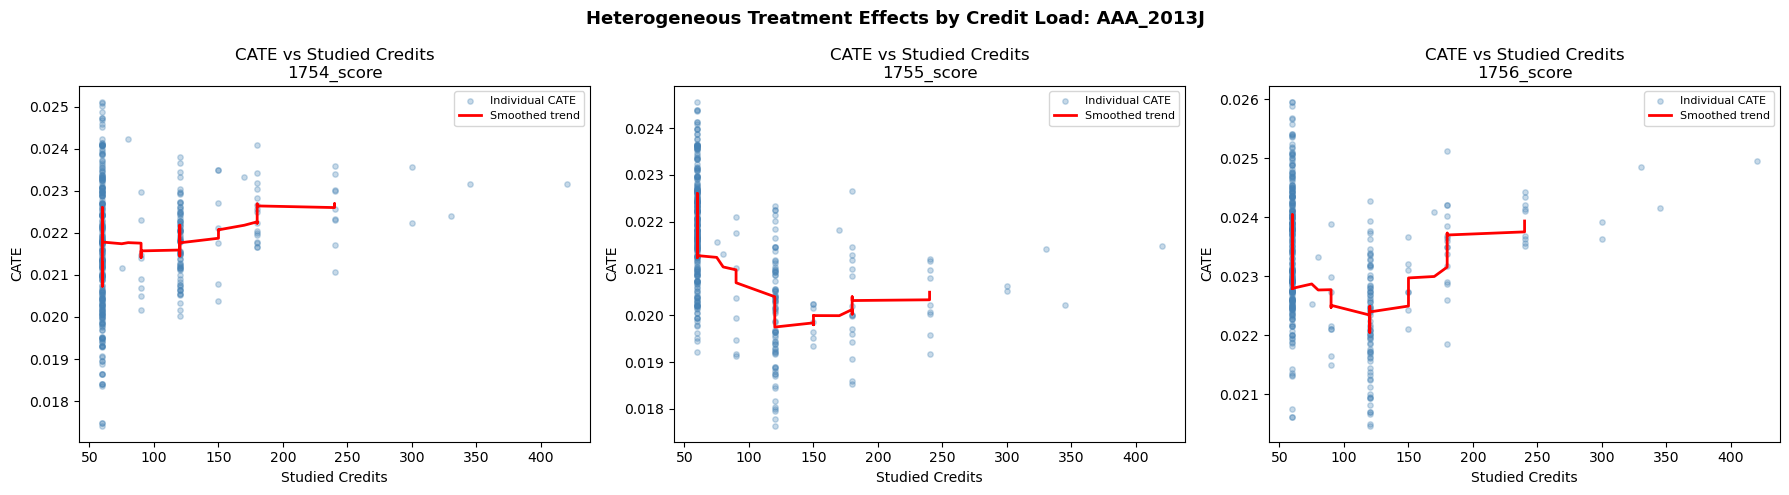

Saved: cate_vs_credits.png


In [34]:
# ── CATE vs studied_credits ────────────────────────────────────────────────────

significant = ['1754_score', '1755_score', '1756_score']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, treatment in enumerate(significant):
    cate = cate_results[treatment]['cate']
    x_var = df_encoded['studied_credits'].values
    
    # Sort by x for clean line plot
    sort_idx = np.argsort(x_var)
    x_sorted = x_var[sort_idx]
    cate_sorted = cate[sort_idx]
    
    # Rolling mean for smoothing
    window = 20
    cate_smooth = pd.Series(cate_sorted).rolling(window, center=True).mean()
    
    ax = axes[i]
    ax.scatter(x_sorted, cate_sorted, alpha=0.3, color='steelblue', s=15, label='Individual CATE')
    ax.plot(x_sorted, cate_smooth, color='red', linewidth=2, label='Smoothed trend')
    ax.set_xlabel('Studied Credits')
    ax.set_ylabel('CATE')
    ax.set_title(f'CATE vs Studied Credits\n{treatment}')
    ax.legend(fontsize=8)

plt.suptitle('Heterogeneous Treatment Effects by Credit Load: AAA_2013J', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cate_vs_credits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cate_vs_credits.png")

  File "C:\Users\Disha Sharma\.conda\envs\analytics\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Disha Sharma\.conda\envs\analytics\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Disha Sharma\.conda\envs\analytics\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Disha Sharma\.conda\envs\analytics\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Disha Sharma\.conda\envs\analytics\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^

  0%|          | 0/383 [00:00<?, ?it/s]

SHAP values computed: total_vle_clicks
Shape: (383, 36)


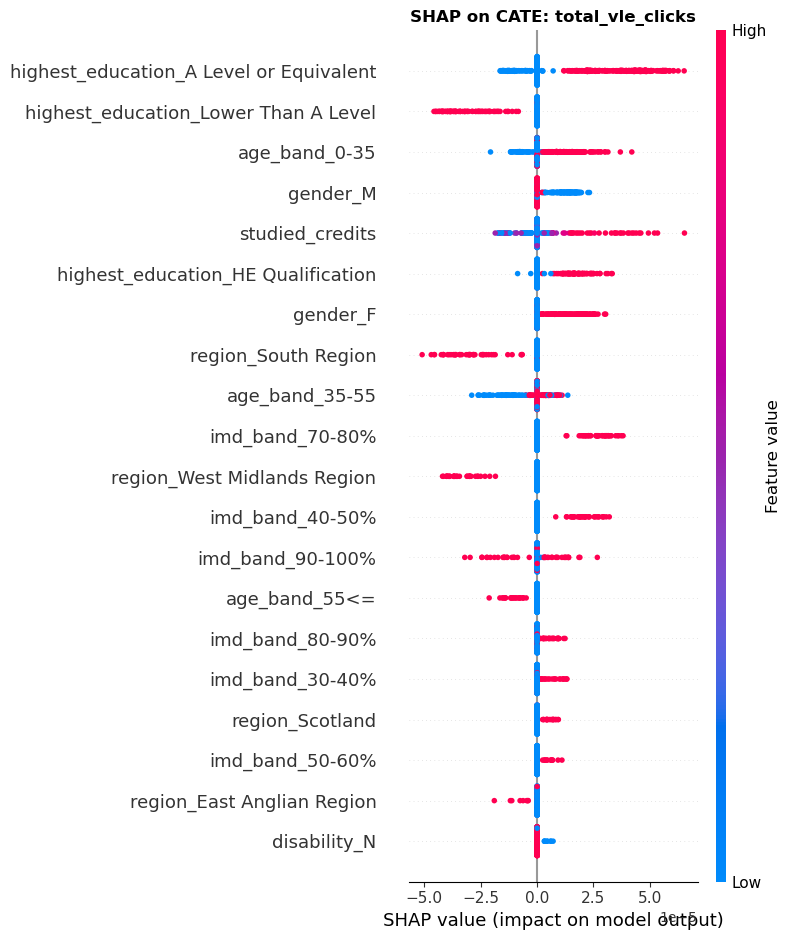

Saved: shap_vle_clicks.png


In [24]:
# ── SHAP on CATE: total_vle_clicks ────────────────────────────────────────────

import shap

X_df = df_encoded[all_confounders]

# Predict function wrapping CausalForestDML
def predict_cate_vle(X):
    return cf_vle.effect(X)

# Use small background sample for speed
background = shap.kmeans(X_df.values, 10)

explainer_vle = shap.KernelExplainer(predict_cate_vle, background)
shap_values_vle = explainer_vle.shap_values(X_df.values, nsamples=100)

print("SHAP values computed: total_vle_clicks")
print(f"Shape: {np.array(shap_values_vle).shape}")

# Summary plot
shap.summary_plot(shap_values_vle, X_df, show=False)
plt.title('SHAP on CATE: total_vle_clicks', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_vle_clicks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_vle_clicks.png")


Computing SHAP for 1752_score...


  0%|          | 0/383 [00:00<?, ?it/s]

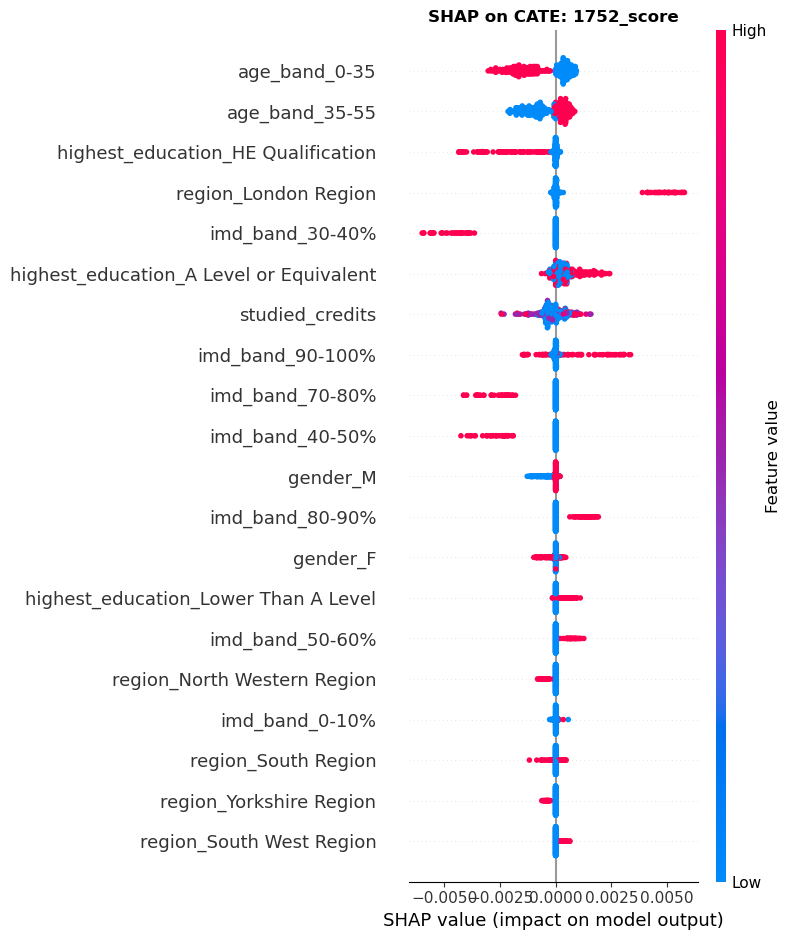

Saved: shap_1752_score.png

Computing SHAP for 1753_score...


  0%|          | 0/383 [00:00<?, ?it/s]

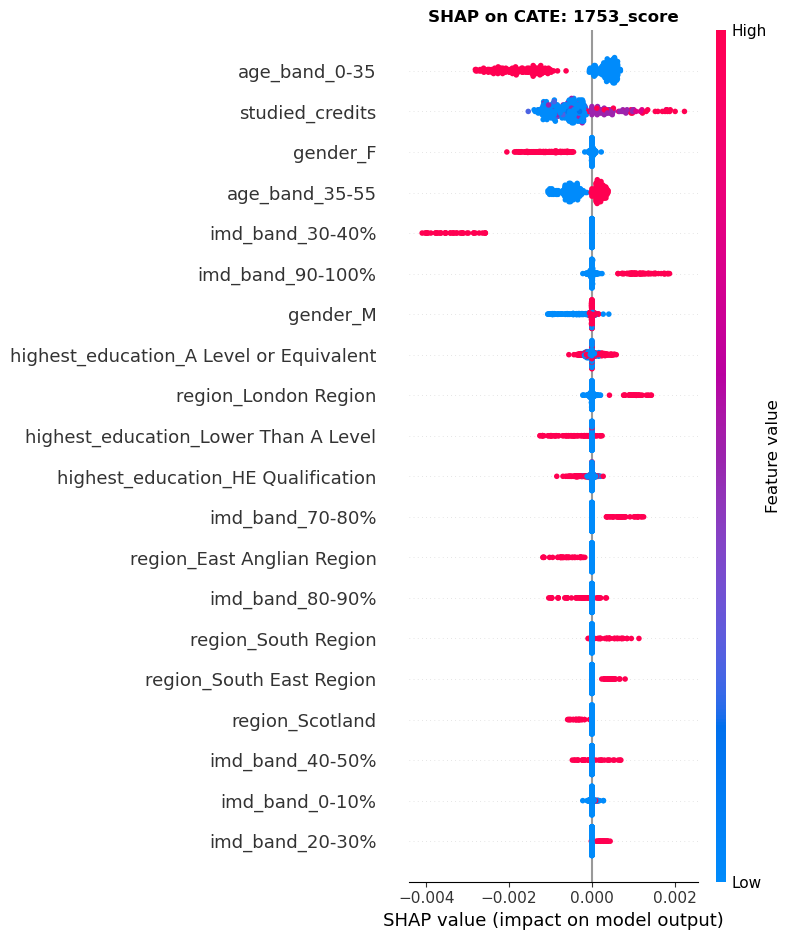

Saved: shap_1753_score.png

Computing SHAP for 1754_score...


  0%|          | 0/383 [00:00<?, ?it/s]

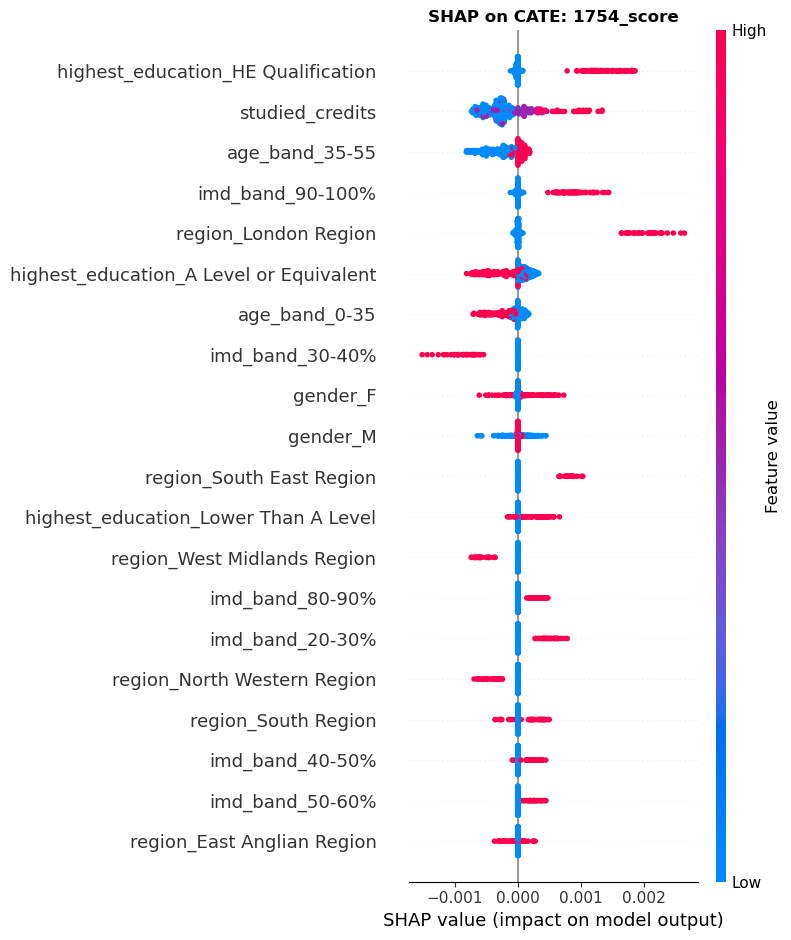

Saved: shap_1754_score.png

Computing SHAP for 1755_score...


  0%|          | 0/383 [00:00<?, ?it/s]

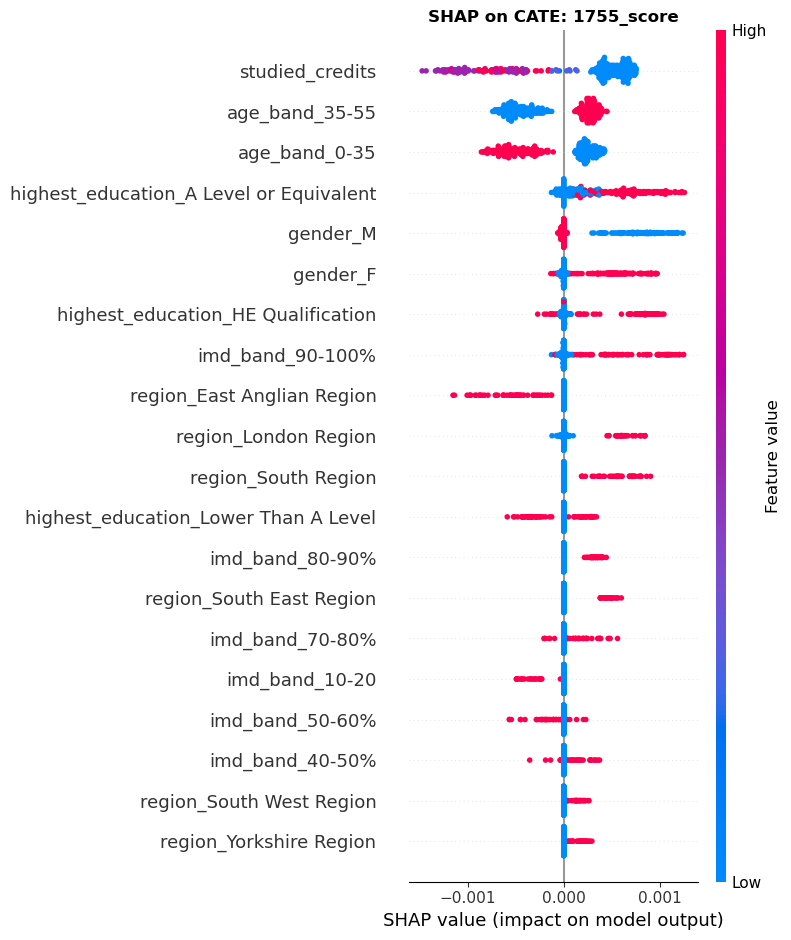

Saved: shap_1755_score.png

Computing SHAP for 1756_score...


  0%|          | 0/383 [00:00<?, ?it/s]

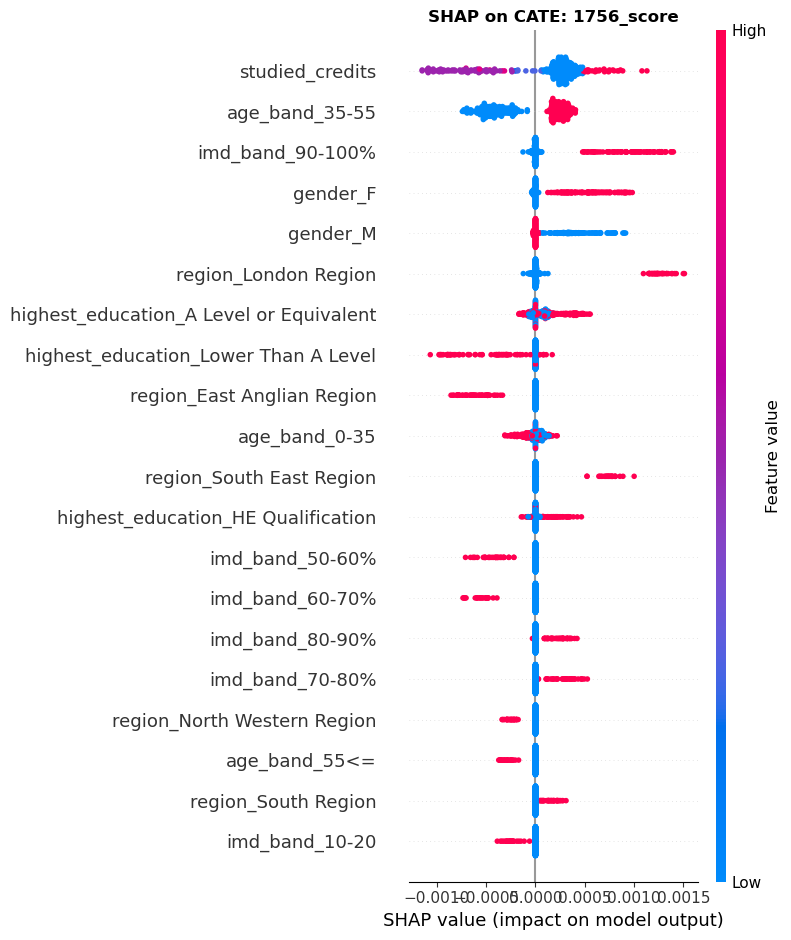

Saved: shap_1756_score.png

Done: all assessment SHAP plots


In [26]:
# ── SHAP on CATE: Assessment Scores ───────────────────────────────────────────

shap_results = {}

for treatment in score_cols:
    print(f"\nComputing SHAP for {treatment}...")
    
    cf_model = cate_results[treatment]['model']
    
    def predict_cate(X):
        return cf_model.effect(X)
    
    explainer = shap.KernelExplainer(predict_cate, background)
    shap_vals = explainer.shap_values(X_df.values, nsamples=100)
    
    shap_results[treatment] = shap_vals
    
    # Summary plot
    shap.summary_plot(shap_vals, X_df, show=False)
    plt.title(f'SHAP on CATE: {treatment}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_{treatment}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_{treatment}.png")

print("\nDone: all assessment SHAP plots")

## Stage 3: SHAP on CATE — Heterogeneity Drivers

### Method
KernelExplainer (SHAP) was applied to the fitted CausalForestDML models to identify 
which student characteristics drive treatment effect heterogeneity. SHAP values here 
represent the contribution of each feature to an individual student's CATE relative 
to the mean CATE — not to the outcome directly. A background sample of 10 cluster 
centroids (k-means) was used for efficiency, with nsamples=100 per explanation.

### Results by Treatment

#### VLE Clicks
Primary drivers: `highest_education`, `age_band_0-35`, `studied_credits`
- Students with A-Level or equivalent education benefit more from VLE engagement
- Younger students (0-35) show higher CATE from online activity
- Students carrying heavier credit loads benefit slightly more from engagement

#### Assessment 1752 (Earliest)
Primary drivers: `age_band_0-35`, `age_band_35-55`, `highest_education_HE`
- Age is the dominant heterogeneity driver at this stage
- Younger students (0-35) show lower CATE — early assessment performance matters 
  less for their final outcome
- Mid-age students (35-55) show higher CATE from early assessment performance

#### Assessment 1753
Primary drivers: `age_band_0-35`, `studied_credits`, `gender_F`
- Age remains dominant; credit load and gender begin to emerge as moderators
- Female students show slightly higher CATE at this stage

#### Assessment 1754 (Mid-module)
Primary drivers: `highest_education_HE`, `studied_credits`, `age_band_35-55`
- Education level takes over from age as the primary heterogeneity driver
- Students with HE qualifications show stronger treatment effects at mid-module

#### Assessment 1755
Primary drivers: `studied_credits`, `age_band_35-55`, `age_band_0-35`
- Credit load becomes the top driver — students studying more credits show 
  stronger causal effects from assessment performance
- Age remains important but secondary

#### Assessment 1756 (Final)
Primary drivers: `studied_credits`, `age_band_35-55`, `gender`
- Credit load and age_band_35-55 consolidate as the dominant drivers by the 
  final assessment
- Gender heterogeneity increases — male and female students diverge in how 
  strongly final assessment performance determines their outcome category

### Interpretation with Respect to Outcome Classes

The SHAP analysis reveals a clear **heterogeneity transition** across the module timeline:

- **Early module (1752–1753)**: Age drives heterogeneity. Younger students and 
  mid-age students respond differently to assessment performance — this likely 
  reflects differences in study habits and prior experience that shape whether 
  early performance translates into Pass/Distinction or Fail/Withdrawal.

- **Mid module (1754)**: Education level takes over. Students with higher prior 
  qualifications extract more causal benefit from mid-module assessments — 
  suggesting that academic preparation moderates the path from assessment 
  performance to final outcome at this stage.

- **Late module (1755–1756)**: Credit load and age_band_35-55 dominate. 
  Students juggling heavier workloads show stronger treatment effects — 
  for these students, final assessment performance is an especially strong 
  determinant of whether they achieve Pass versus Distinction or tip into 
  Fail versus Withdrawal.

### Central Finding
The causal effect of assessment performance on student outcome (Withdrawn/Fail/Pass/
Distinction) strengthens and becomes more uniform as the module progresses. Early 
assessments have heterogeneous effects moderated primarily by age; late assessments 
have strong, near-uniform effects moderated primarily by credit load. This suggests 
that targeted early intervention — particularly for mid-age students with heavy credit 
loads — could shift students from Withdrawn/Fail trajectories toward Pass/Distinction.